In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from parameters import *
from omega_loop.calculated_params import *
from openEMS.physical_constants import *
workspace_root = os.getcwd()

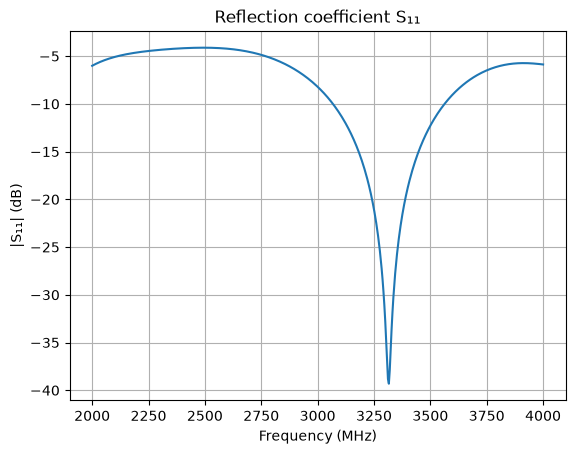

In [3]:
freq = np.linspace(f0 - fc, f0 + fc, 501)
plt.plot(freq/1e6,20 * np.log10(np.abs(s11)))
plt.xlabel('Frequency (MHz)')
plt.ylabel('|S₁₁| (dB)')
plt.title('Reflection coefficient S₁₁')
plt.grid()
plt.show()

In [4]:
h5_path = os.path.join(workspace_root, 'omega_loop', 'HField.h5')
with h5py.File(h5_path, 'r') as f:
    x = f['Mesh/x'][:] / unit             
    y = f['Mesh/y'][:] / unit             
    z = f['Mesh/z'][:] / unit             
    real = f['FieldData/FD/f0_real'][:]   # (3, Nz, Ny, Nx)
    imag = f['FieldData/FD/f0_imag'][:]
    print("\n=== Full structure ===")
    def show(name, obj):
        kind = 'Group' if isinstance(obj, h5py.Group) else 'Dataset'
        extra = f" shape={obj.shape} dtype={obj.dtype}" if kind == 'Dataset' else ""
        print(f"{kind}: {name}{extra}")
        if hasattr(obj, 'attrs') and len(obj.attrs):
            print(f"    attrs: {dict(obj.attrs)}")
    f.visititems(show)


=== Full structure ===
Group: FieldData
Group: FieldData/FD
    attrs: {'frequency': array([2.87e+09])}
Dataset: FieldData/FD/f0_imag shape=(3, 5, 56, 54) dtype=float32
    attrs: {'frequency': array([2.87e+09], dtype=float32)}
Dataset: FieldData/FD/f0_real shape=(3, 5, 56, 54) dtype=float32
    attrs: {'frequency': array([2.87e+09], dtype=float32)}
Group: Mesh
Dataset: Mesh/x shape=(54,) dtype=float32
Dataset: Mesh/y shape=(56,) dtype=float32
Dataset: Mesh/z shape=(5,) dtype=float32


In [5]:
print(z-gap_diamond)

[-0.187875  0.15      0.48      0.829     1.2177  ]


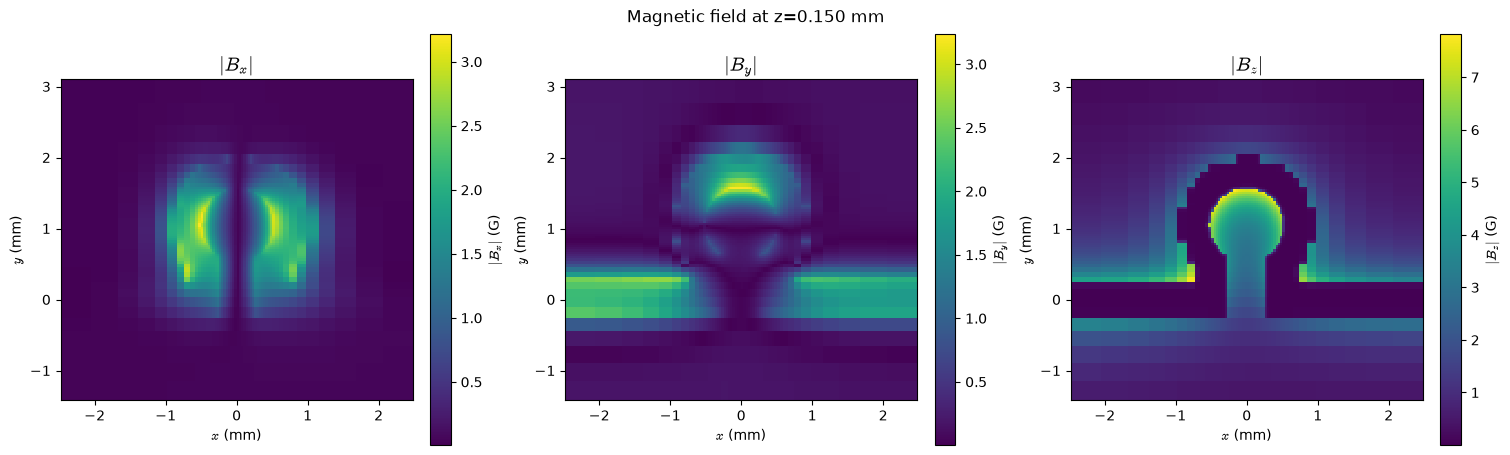

In [6]:
plane_of_analysis = 1
P_dbm=40
Power = (10 ** ((P_dbm - 30) / 10))*(1-abs(np.interp(f_meas,freq,s11)))                      # dBm->W 0dBm=1e-3W
# Optional: for power actually accepted by the loop, use Power*(1-abs(s11_f0)**2)

H_all   = real + 1j * imag                         # A/m  (complex phasor)
B_all_T = MUE0 * H_all * np.sqrt(Power / P0_in)    # T    (used for all calculations)
B_all   = B_all_T * 1e4                            # G    (used for plots only)

X, Y = np.meshgrid(x, y, indexing='xy')
Bx_MW = B_all[0, plane_of_analysis, :, :]
By_MW = B_all[1, plane_of_analysis, :, :]
Bz_MW = B_all[2, plane_of_analysis, :, :]

Bx_mag = np.abs(Bx_MW)
By_mag = np.abs(By_MW)
Bz_mag = np.abs(Bz_MW)

plt.rcParams.update({"mathtext.fontset": "cm"})
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
components = [(Bx_mag, r'$|B_x|$'), (By_mag, r'$|B_y|$'), (Bz_mag, r'$|B_z|$')]
for ax, (Bc, title) in zip(axes, components):
    pcm = ax.pcolormesh(X, Y, Bc, cmap='viridis', shading='auto')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r'$x$ (mm)')
    ax.set_ylabel(r'$y$ (mm)')
    ax.set_aspect('equal')
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(title + r' (G)')
plt.suptitle(f"Magnetic field at z={z[plane_of_analysis]:.3f} mm")
plt.show()

In [7]:
def get_rotation_matrix_lat(idx_nv):
    """Rotation matrix R (det = +1) from the crystal (lab) frame to the frame of NV
    orientation idx_nv (1-4): B_NV = R @ B_lab. Third row = NV axis (<111> direction),
    first two rows = transverse axes."""
    if idx_nv == 1:
        RNV = np.array([[ 1/np.sqrt(2), -1/np.sqrt(2),  0],
                        [ 1/np.sqrt(6),  1/np.sqrt(6), -2/np.sqrt(6)],
                        [ 1/np.sqrt(3),  1/np.sqrt(3),  1/np.sqrt(3)]])
    elif idx_nv == 2:
        RNV = np.array([[ 1/np.sqrt(2),  1/np.sqrt(2),  0],
                        [ 1/np.sqrt(6), -1/np.sqrt(6),  2/np.sqrt(6)],
                        [ 1/np.sqrt(3), -1/np.sqrt(3), -1/np.sqrt(3)]])
    elif idx_nv == 3:
        RNV = np.array([[-1/np.sqrt(2), -1/np.sqrt(2),  0],
                        [-1/np.sqrt(6),  1/np.sqrt(6),  2/np.sqrt(6)],
                        [-1/np.sqrt(3),  1/np.sqrt(3), -1/np.sqrt(3)]])
    elif idx_nv == 4:
        RNV = np.array([[-1/np.sqrt(2),  1/np.sqrt(2),  0],
                        [-1/np.sqrt(6), -1/np.sqrt(6), -2/np.sqrt(6)],
                        [-1/np.sqrt(3), -1/np.sqrt(3),  1/np.sqrt(3)]])
    else:
        raise ValueError("idx_nv must be 1, 2, 3 or 4")
    return RNV

for i in range(1, 5):
    R_ = get_rotation_matrix_lat(i)
    assert np.allclose(R_ @ R_.T, np.eye(3)) and np.isclose(np.linalg.det(R_), 1.0)

In [8]:
import qutip as qu
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
orange_cmap = LinearSegmentedColormap.from_list("black_orange_white", ["black", "orange", "white"])

# Static (bias) magnetic field in the NV frame (T)
B0x = 0.0
B0y = 0.0
B0z = 0.0

gamma = 2*np.pi*28e9      # rad s^-1 T^-1  (gamma_e/2pi = 28 GHz/T)
D     = 2*np.pi*2.87e9    # rad s^-1       (zero-field splitting, no per-tesla dependence)

In [9]:
Sx = qu.jmat(1, 'x')
Sy = qu.jmat(1, 'y')
Sz = qu.jmat(1, 'z')

In [10]:
H0 = D * (Sz**2) + gamma * (B0x*Sx + B0y*Sy + B0z*Sz)     # rad s^-1  (hbar = 1)

In [11]:
eigenvalues, eigenstates = H0.eigenstates()
print("Eigenvalues (rad/s):", eigenvalues)
print("Eigenvalues/2pi (GHz):", eigenvalues/(2*np.pi*1e9))

# Basis ordering of qutip.jmat(1): [m=+1, m=0, m=-1].
# At B0 = 0 the m=+/-1 levels are degenerate, so eigenstates() may return arbitrary
d = qu.basis(3, 0)    # |m = +1>
g = qu.basis(3, 1)    # |m =  0>
b = qu.basis(3, 2)    # |m = -1>

Eigenvalues (rad/s): [0.00000000e+00 1.80327418e+10 1.80327418e+10]
Eigenvalues/2pi (GHz): [0.   2.87 2.87]


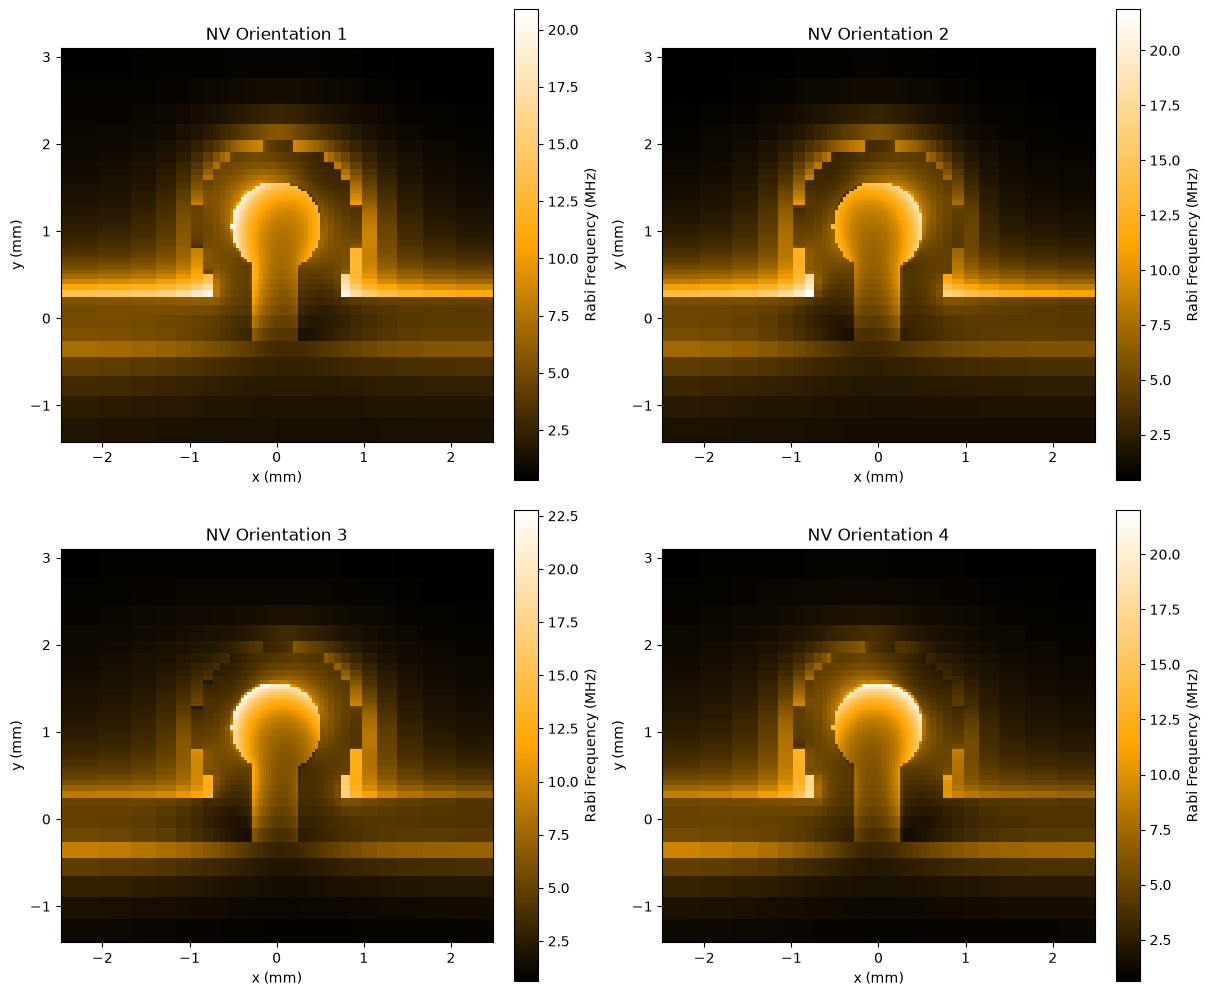

In [12]:
# ------------------------------------------------------------------
# Rabi frequency maps for the four NV orientations
# ------------------------------------------------------------------
B_T = B_all_T[:, plane_of_analysis]           # (3, Ny, Nx), complex, tesla
transition = 'bright'   # 'plus'  : |0> -> |+1>
                        # 'minus' : |0> -> |-1>   (which of the two is which depends on the phasor sign convention)
                        # 'bright': |0> -> bright state at B0 = 0, sqrt(Om_p^2 + Om_m^2) = gamma*sqrt(|Bx|^2+|By|^2)

pref = gamma / np.sqrt(2) / (2*np.pi) / 1e6   # -> MHz (ordinary frequency, Omega/2pi)

def rabi_maps_MHz(B_nv):
    Om_p = pref * np.abs(B_nv[0] + 1j*B_nv[1])
    Om_m = pref * np.abs(B_nv[0] - 1j*B_nv[1])
    return Om_p, Om_m, np.hypot(Om_p, Om_m)

# cross-check analytic formula against qutip at one pixel (rad/s)
_iy, _ix = np.unravel_index(np.argmax(np.abs(B_T[0])), B_T[0].shape)
_bx, _by, _bz = (B_T[k, _iy, _ix] for k in range(3))
_Hmw = gamma * (_bx*Sx + _by*Sy + _bz*Sz)
assert np.isclose(abs((g.dag() * _Hmw * d)), gamma/np.sqrt(2)*abs(_bx + 1j*_by), rtol=1e-6)

maps = {}
for idx_nv in [1, 2, 3, 4]:
    B_nv = np.einsum('ij,jkl->ikl', get_rotation_matrix_lat(idx_nv), B_T)
    Om_p, Om_m, Om_b = rabi_maps_MHz(B_nv)
    maps[idx_nv] = {'plus': Om_p, 'minus': Om_m, 'bright': Om_b}[transition]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

for idx_nv, ax in zip([1, 2, 3, 4], axes.ravel()):

    R = maps[idx_nv]                         # already in MHz
    pcm = ax.pcolormesh(x, y, R, shading="auto", cmap=orange_cmap)

    ax.set_title(f"NV Orientation {idx_nv}")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_aspect("equal")

    fig.colorbar(pcm, ax=ax, label="Rabi Frequency (MHz)")

plt.show()

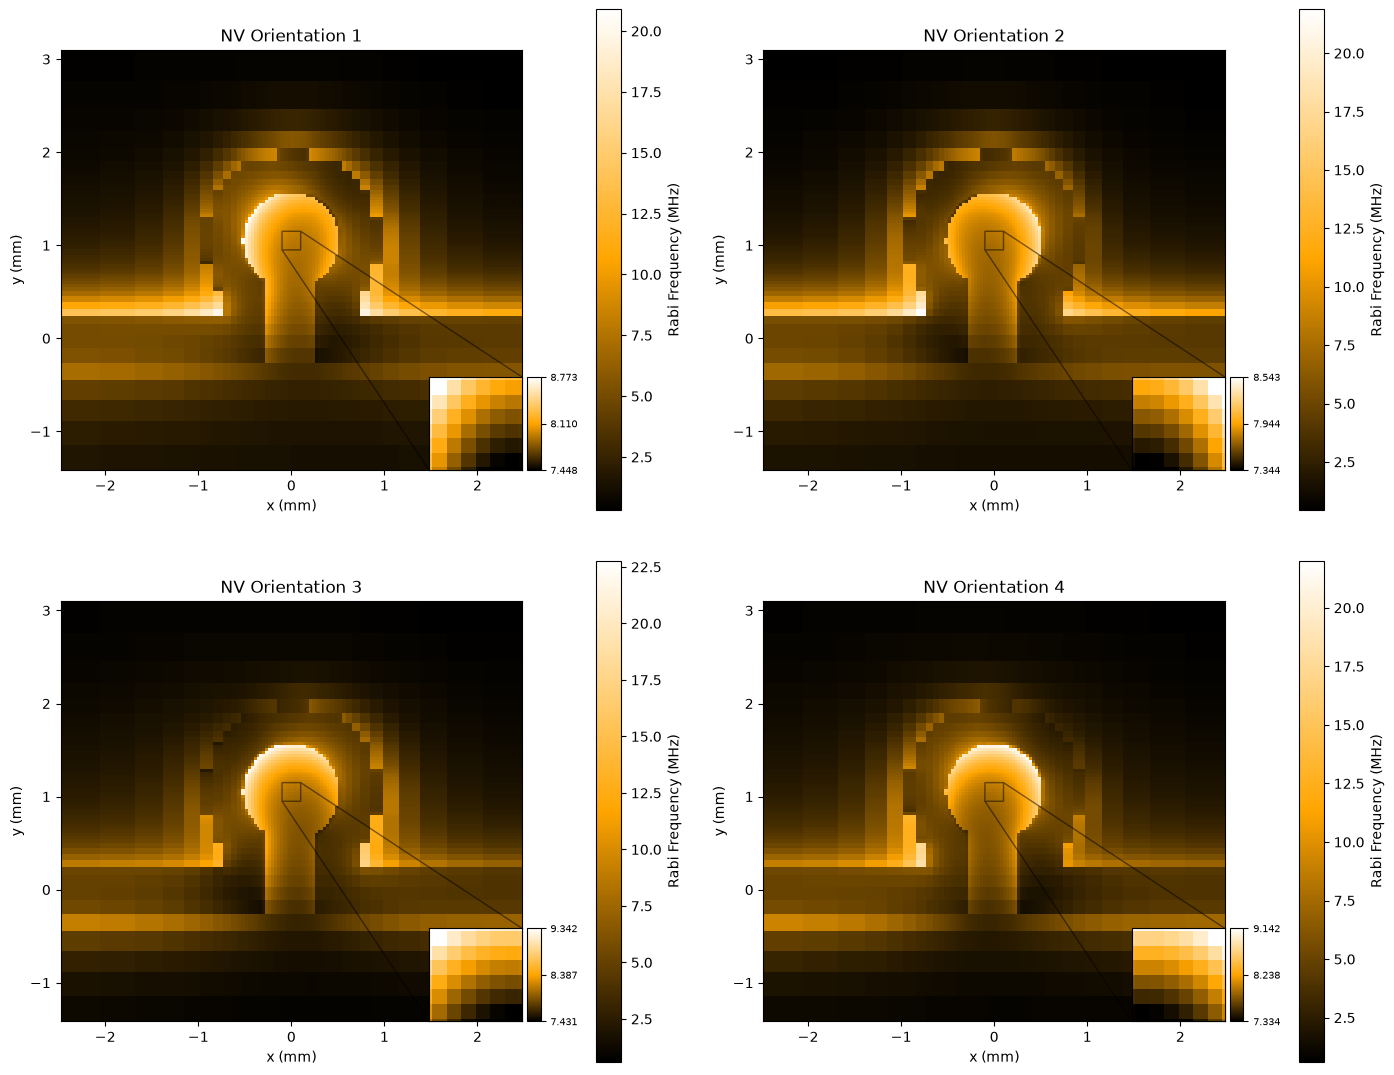

In [13]:
shared_main_scale = False     # True -> same colour limits for the big colourbar in all 4 panels
inset_side = 1.0              # side of the zoom-inset box, in mm (data units)

x1, x2 = -0.1, 0.1              #100um x 100um
y1, y2 = -0.1 + feed_width/2 + inner_rad + circle_hight, 0.1 + feed_width/2 + inner_rad +circle_hight

vmin_all = min(m.min() for m in maps.values())
vmax_all = max(m.max() for m in maps.values())

fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)
for idx_nv, ax in zip([1, 2, 3, 4], axes.ravel()):
    R = maps[idx_nv]                                   # already in MHz
    vmin, vmax = (vmin_all, vmax_all) if shared_main_scale else (R.min(), R.max())

    # ---- main map + BIG colourbar (far right) ----
    pcm = ax.pcolormesh(x, y, R, shading="auto", cmap=orange_cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f"NV Orientation {idx_nv}")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_aspect("equal")
    fig.colorbar(pcm, ax=ax, pad=0.16, label="Rabi Frequency (MHz)")

    # ---- zoom inset: square box in the bottom-right corner ----
    xl, yl = ax.get_xlim(), ax.get_ylim()
    w_pct = 100 * inset_side / (xl[1] - xl[0])         # square on screen (parent aspect is equal)
    h_pct = 100 * inset_side / (yl[1] - yl[0])
    axins = inset_axes(ax, width=f"{w_pct}%", height=f"{h_pct}%", loc="lower right", borderpad=0)

    sub = R[np.ix_((y >= y1) & (y <= y2), (x >= x1) & (x <= x2))]
    lo, hi = (sub.min(), sub.max()) if sub.size else (R.min(), R.max())
    if np.isclose(lo, hi):
        lo, hi = lo - 1e-3, hi + 1e-3

    pcm2 = axins.pcolormesh(x, y, R, shading="auto", cmap=orange_cmap, vmin=lo, vmax=hi)
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_aspect("equal")
    ax.indicate_inset_zoom(axins, edgecolor="black")

    cax = inset_axes(ax, width="3%", height=f"{h_pct}%", loc="lower left",
                     bbox_to_anchor=(1.01, 0, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
    cb2 = fig.colorbar(pcm2, cax=cax)
    cb2.set_ticks(np.linspace(lo, hi, 3))
    cb2.ax.tick_params(labelsize=7)
    cb2.ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.3f"))
plt.show()